In [1]:
import os
from pathlib import Path

BASE_DIR = None
for candidate in [Path("/Users/martateodoratrales/Desktop/AirPanel"), Path.cwd(), Path.cwd().parent]:
    if (candidate / "embedding_comparison_outputs" / "df_allq_with_embeddings_metadata.csv").exists():
        BASE_DIR = candidate
        break
if BASE_DIR is None:
    raise FileNotFoundError("embedding_comparison_outputs with metadata CSV not found")

CACHE_DIR = Path("/tmp/airpanel_matplotlib_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(CACHE_DIR)

import numpy as np
import pandas as pd
import matplotlib
from IPython import get_ipython
if get_ipython() is None:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid")

EMB_DIR = BASE_DIR / "embedding_comparison_outputs"
def pick_output_dir(preferred):
    for candidate in [preferred, Path.cwd() / "embedding_inspection_outputs", Path("/tmp/embedding_inspection_outputs")]:
        try:
            candidate.mkdir(parents=True, exist_ok=True)
            probe = candidate / ".write_test"
            probe.write_text("ok")
            probe.unlink()
            return candidate
        except Exception:
            continue
    raise PermissionError("No writable output directory found")

OUTPUT_DIR = pick_output_dir(BASE_DIR / "embedding_inspection_outputs")
print(BASE_DIR)
print(OUTPUT_DIR)


/Users/martateodoratrales/Desktop/AirPanel
/Users/martateodoratrales/Desktop/AirPanel/embedding_inspection_outputs


In [2]:
metadata = pd.read_csv(EMB_DIR / "df_allq_with_embeddings_metadata.csv")
group_summary = pd.read_csv(EMB_DIR / "embedding_group_summary.csv")
group_pairs = pd.read_csv(EMB_DIR / "embedding_group_centroid_pairs.csv")
family_summary = pd.read_csv(EMB_DIR / "embedding_family_comparison.csv")
paired_similarity = pd.read_csv(EMB_DIR / "embedding_panelist_paired_similarity.csv")
comparison_summary = pd.read_csv(EMB_DIR / "embedding_comparison_questions_vs_group_centroids.csv")
sim_matrix = pd.read_csv(EMB_DIR / "embedding_question_centroid_similarity_matrix.csv", index_col=0)

EMB_COLS = [c for c in metadata.columns if c.startswith("emb_")]

print(metadata.shape)
print(group_summary.shape, group_pairs.shape, family_summary.shape, paired_similarity.shape, comparison_summary.shape, sim_matrix.shape)


(17600, 391)
(3, 5) (3, 4) (8, 9) (8, 5) (6, 5) (16, 16)


In [3]:
overview = pd.DataFrame(
    {
        "table": [
            "metadata",
            "group_summary",
            "group_pairs",
            "family_summary",
            "paired_similarity",
            "comparison_summary",
            "similarity_matrix",
        ],
        "rows": [
            len(metadata),
            len(group_summary),
            len(group_pairs),
            len(family_summary),
            len(paired_similarity),
            len(comparison_summary),
            len(sim_matrix),
        ],
        "cols": [
            metadata.shape[1],
            group_summary.shape[1],
            group_pairs.shape[1],
            family_summary.shape[1],
            paired_similarity.shape[1],
            comparison_summary.shape[1],
            sim_matrix.shape[1],
        ],
    }
)

data_quality = pd.DataFrame(
    {
        "metric": [
            "n_panelists",
            "n_questions",
            "n_groups",
            "embedding_dimensions",
            "missing_text_share",
            "missing_embedding_cells",
        ],
        "value": [
            metadata["panelist_id"].nunique(),
            metadata["Question"].nunique(),
            metadata["group"].nunique(),
            len(EMB_COLS),
            round(float((metadata["text"].fillna("").str.strip() == "").mean()), 6),
            int(metadata[EMB_COLS].isna().sum().sum()),
        ],
    }
)

overview.to_csv(OUTPUT_DIR / "inspection_overview.csv", index=False)
data_quality.to_csv(OUTPUT_DIR / "inspection_data_quality.csv", index=False)
overview


,table,rows,cols
0,metadata,17600,391
1,group_summary,3,5
2,group_pairs,3,4
3,family_summary,8,9
4,paired_similarity,8,5
5,comparison_summary,6,5
6,similarity_matrix,16,16


In [4]:
group_text = metadata.groupby("group", as_index=False).agg(
    n_answers=("text", "size"),
    n_panelists=("panelist_id", "nunique"),
    median_text_len=("text_len", "median"),
)

emb_norms = np.linalg.norm(metadata[EMB_COLS].to_numpy(dtype=float), axis=1)
metadata["embedding_norm"] = emb_norms
norm_stats = metadata.groupby("group", as_index=False).agg(
    mean_embedding_norm=("embedding_norm", "mean"),
    std_embedding_norm=("embedding_norm", "std"),
)

group_diagnostics = group_summary.merge(group_text, on=["group", "n_answers", "n_panelists"], how="left").merge(norm_stats, on="group", how="left")
group_diagnostics["cohesion_rank"] = group_diagnostics["mean_distance_to_centroid"].rank(method="dense")
group_diagnostics = group_diagnostics.sort_values("mean_distance_to_centroid")
group_diagnostics.to_csv(OUTPUT_DIR / "inspection_group_diagnostics.csv", index=False)
group_diagnostics


/var/folders/k9/89sz9rmn25s78pr1yz7ytdz40000gn/T/ipykernel_63802/3826458904.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metadata["embedding_norm"] = emb_norms


,group,n_answers,n_panelists,mean_text_len,mean_distance_to_centroid,median_text_len,mean_embedding_norm,std_embedding_norm,cohesion_rank
1,Comparison,4800,800,221.576667,0.656980,212.0,1.0,3.399255e-08,1.0
0,Bouygues,6400,800,229.275469,0.708373,228.0,1.0,3.524743e-08,2.0
2,Orange,6400,800,214.590625,0.721984,212.0,1.0,3.462974e-08,3.0


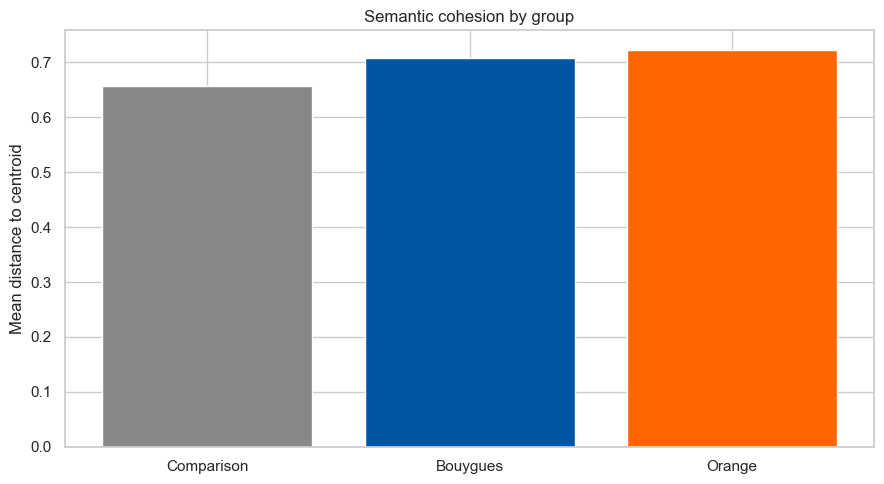

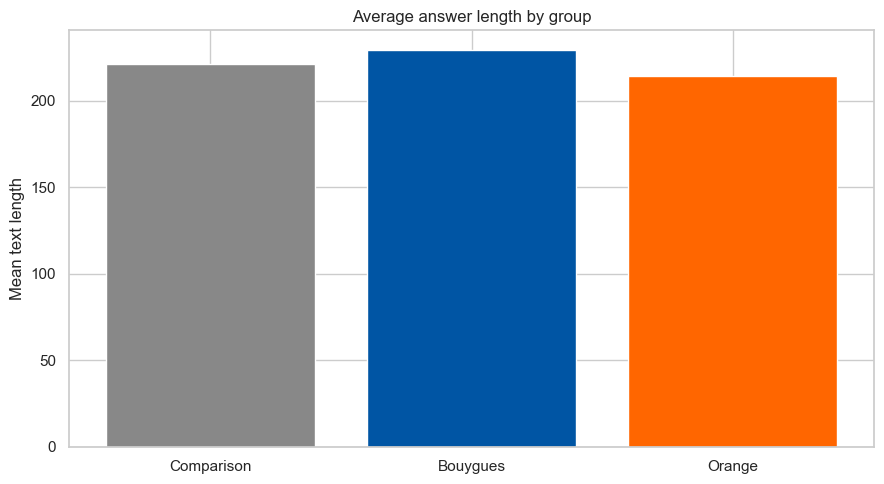

In [5]:
plt.figure(figsize=(9, 5))
order = group_diagnostics["group"]
plt.bar(order, group_diagnostics["mean_distance_to_centroid"], color=["#888888", "#0055A4", "#FF6600"])
plt.ylabel("Mean distance to centroid")
plt.title("Semantic cohesion by group")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inspection_group_cohesion.png", dpi=300)
plt.show()
plt.close()

plt.figure(figsize=(9, 5))
plt.bar(order, group_diagnostics["mean_text_len"], color=["#888888", "#0055A4", "#FF6600"])
plt.ylabel("Mean text length")
plt.title("Average answer length by group")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inspection_group_text_length.png", dpi=300)
plt.show()
plt.close()


In [6]:
pair_diagnostics = group_pairs.copy()
pair_diagnostics["similarity_rank_desc"] = pair_diagnostics["centroid_cosine_similarity"].rank(ascending=False, method="dense")
pair_diagnostics["distance_rank_desc"] = pair_diagnostics["centroid_euclidean_distance"].rank(ascending=False, method="dense")
pair_diagnostics = pair_diagnostics.sort_values("centroid_cosine_similarity", ascending=False)
pair_diagnostics.to_csv(OUTPUT_DIR / "inspection_group_pair_diagnostics.csv", index=False)
pair_diagnostics


,group_a,group_b,centroid_cosine_similarity,centroid_euclidean_distance,similarity_rank_desc,distance_rank_desc
1,Bouygues,Orange,0.958144,0.202194,1.0,3.0
2,Comparison,Orange,0.840381,0.411508,2.0,2.0
0,Bouygues,Comparison,0.773886,0.491390,3.0,1.0


In [7]:
if "mean_len_bouygues" not in family_summary.columns or "mean_len_orange" not in family_summary.columns:
    family_lengths = (
        metadata[metadata["group"].isin(["Bouygues", "Orange"])]
        .groupby(["group", "family"], as_index=False)["text_len"]
        .mean()
        .pivot(index="family", columns="group", values="text_len")
        .reset_index()
        .rename(columns={"Bouygues": "mean_len_bouygues", "Orange": "mean_len_orange"})
    )
    family_summary = family_summary.merge(family_lengths, on="family", how="left")

family_diagnostics = family_summary.merge(paired_similarity, on="family", how="left")
family_diagnostics["semantic_gap"] = 1 - family_diagnostics["cosine_similarity"]
family_diagnostics["text_length_gap"] = family_diagnostics["mean_len_bouygues"] - family_diagnostics["mean_len_orange"]
family_diagnostics["dispersion_gap"] = family_diagnostics["bouygues_dispersion"] - family_diagnostics["orange_dispersion"]
family_diagnostics = family_diagnostics.sort_values("cosine_similarity")
family_diagnostics.to_csv(OUTPUT_DIR / "inspection_family_diagnostics.csv", index=False)
family_diagnostics


,family,n_bouygues,n_orange,cosine_similarity,euclidean_distance,bouygues_dispersion,orange_dispersion,mean_len_bouygues,mean_len_orange,n_pairs,mean_panelist_cosine,median_panelist_cosine,std_panelist_cosine,semantic_gap,text_length_gap,dispersion_gap
0,reactions_spontanees_1,800,800,0.788425,0.524819,0.570693,0.603715,213.99750,179.66000,800,0.516255,0.516425,0.061271,0.211575,34.33750,-0.033021
1,memorisation_1,800,800,0.829885,0.442643,0.645053,0.650008,266.75875,255.49375,800,0.485752,0.486864,0.071846,0.170115,11.26500,-0.004955
2,caractere_distinctif_1,800,800,0.851203,0.427213,0.597281,0.645086,247.01000,231.68875,800,0.522645,0.523390,0.080752,0.148797,15.32125,-0.047804
3,image_1,800,800,0.862193,0.420695,0.586094,0.603317,218.21000,217.07125,800,0.562696,0.567457,0.075417,0.137807,1.13875,-0.017223
4,intention_achat_1,800,800,0.867880,0.379234,0.690937,0.655012,228.12000,235.57875,800,0.474694,0.478314,0.081782,0.132120,-7.45875,0.035925
5,resonance_emotionnelle_1,800,800,0.883783,0.367508,0.633864,0.653168,176.99500,173.22500,800,0.511194,0.511321,0.071385,0.116217,3.77000,-0.019304
6,attractivite_1,800,800,0.921046,0.290213,0.675678,0.686473,235.70500,226.42375,800,0.494864,0.493825,0.066695,0.078954,9.28125,-0.010795
7,attractivite_2,800,800,0.929636,0.279917,0.668059,0.658959,247.40750,197.58375,800,0.519343,0.520261,0.073867,0.070364,49.82375,0.009099


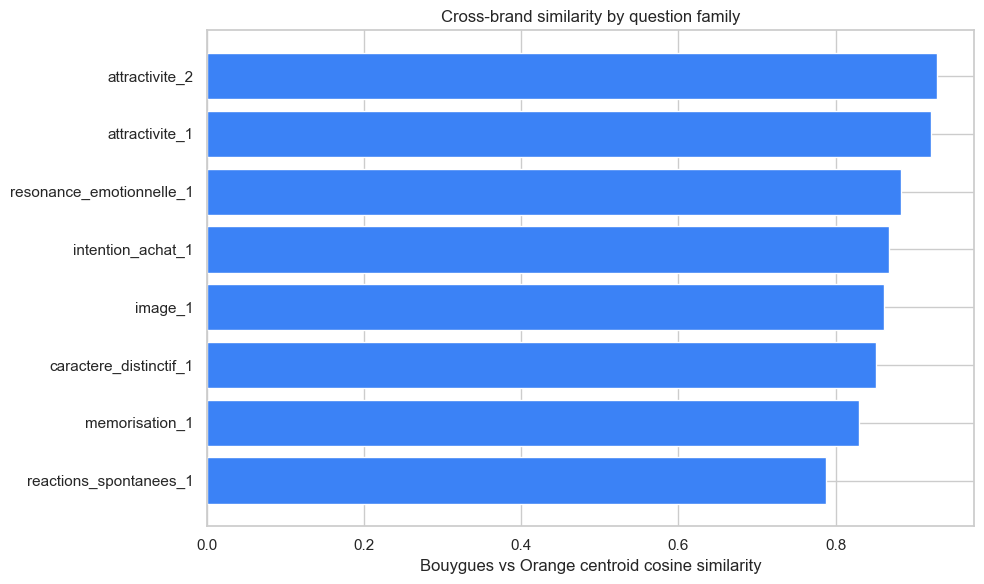

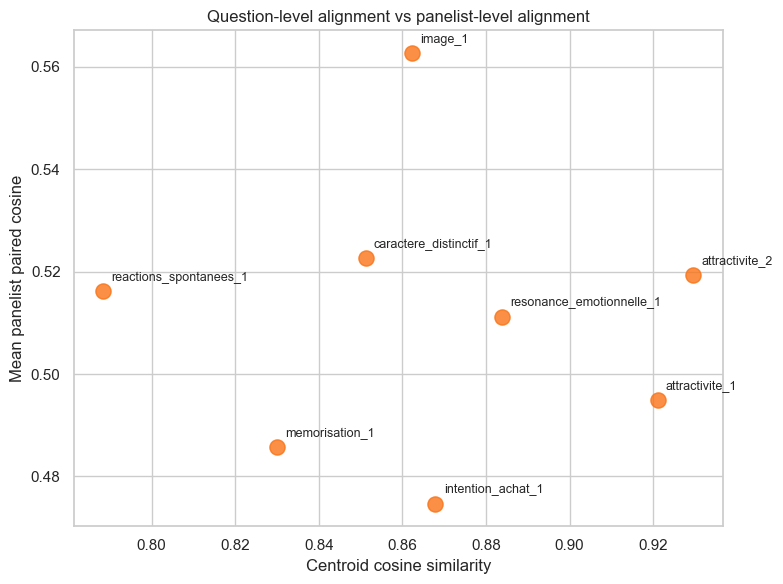

In [8]:
plt.figure(figsize=(10, 6))
plot_df = family_diagnostics.sort_values("cosine_similarity")
plt.barh(plot_df["family"], plot_df["cosine_similarity"], color="#3B82F6")
plt.xlabel("Bouygues vs Orange centroid cosine similarity")
plt.title("Cross-brand similarity by question family")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inspection_family_similarity.png", dpi=300)
plt.show()
plt.close()

plt.figure(figsize=(8, 6))
plt.scatter(
    family_diagnostics["cosine_similarity"],
    family_diagnostics["mean_panelist_cosine"],
    s=120,
    c="#F97316",
    alpha=0.8,
)
for _, row in family_diagnostics.iterrows():
    plt.text(row["cosine_similarity"] + 0.002, row["mean_panelist_cosine"] + 0.002, row["family"], fontsize=9)
plt.xlabel("Centroid cosine similarity")
plt.ylabel("Mean panelist paired cosine")
plt.title("Question-level alignment vs panelist-level alignment")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inspection_family_alignment_scatter.png", dpi=300)
plt.show()
plt.close()


In [9]:
comparison_diagnostics = comparison_summary.copy()
comparison_diagnostics["orange_minus_bouygues"] = comparison_diagnostics["cosine_to_orange_centroid"] - comparison_diagnostics["cosine_to_bouygues_centroid"]
comparison_diagnostics["nearest_brand"] = np.where(
    comparison_diagnostics["cosine_to_orange_centroid"] >= comparison_diagnostics["cosine_to_bouygues_centroid"],
    "Orange",
    "Bouygues",
)
comparison_diagnostics = comparison_diagnostics.sort_values("orange_minus_bouygues", ascending=False)
comparison_diagnostics.to_csv(OUTPUT_DIR / "inspection_comparison_question_diagnostics.csv", index=False)
comparison_diagnostics


,comparison_family,n_answers,cosine_to_bouygues_centroid,cosine_to_orange_centroid,cosine_to_comparison_centroid,orange_minus_bouygues,nearest_brand
4,comparaison_5,800,0.734175,0.814556,0.953562,0.080381,Orange
5,comparaison_6,800,0.665879,0.745176,0.934232,0.079297,Orange
0,comparaison_1,800,0.736884,0.804463,0.952069,0.067579,Orange
3,comparaison_4,800,0.685622,0.748713,0.906650,0.063091,Orange
1,comparaison_2,800,0.737505,0.782095,0.946559,0.044590,Orange
2,comparaison_3,800,0.782521,0.821059,0.918267,0.038538,Orange


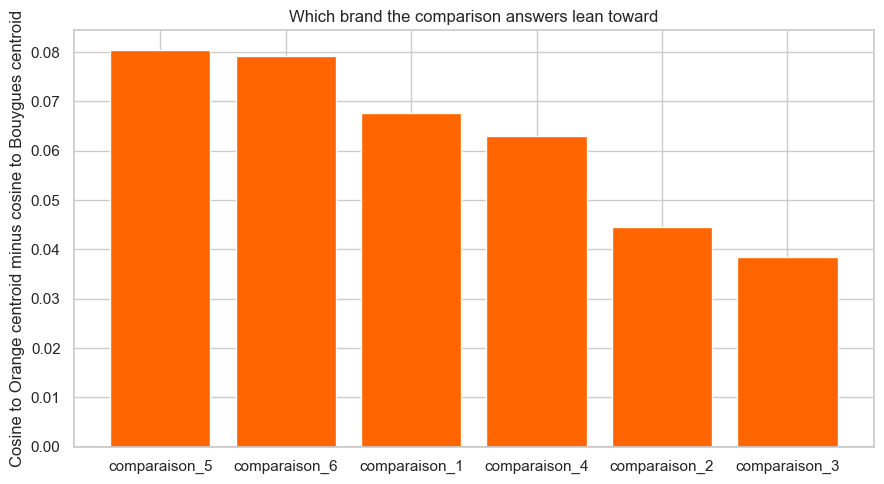

In [10]:
plt.figure(figsize=(9, 5))
colors = ["#FF6600" if x >= 0 else "#0055A4" for x in comparison_diagnostics["orange_minus_bouygues"]]
plt.bar(comparison_diagnostics["comparison_family"], comparison_diagnostics["orange_minus_bouygues"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Cosine to Orange centroid minus cosine to Bouygues centroid")
plt.title("Which brand the comparison answers lean toward")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inspection_comparison_brand_lean.png", dpi=300)
plt.show()
plt.close()


In [11]:
matrix_long = (
    sim_matrix.stack()
    .reset_index()
    .rename(columns={"level_0": "question_a", "level_1": "question_b", 0: "cosine_similarity"})
)
matrix_long = matrix_long[matrix_long["question_a"] != matrix_long["question_b"]].copy()
matrix_long["pair_key"] = matrix_long.apply(lambda r: " || ".join(sorted([r["question_a"], r["question_b"]])), axis=1)
matrix_long = matrix_long.drop_duplicates("pair_key").drop(columns="pair_key")
matrix_long = matrix_long.sort_values("cosine_similarity")

lowest_pairs = matrix_long.head(15).copy()
highest_pairs = matrix_long.tail(15).sort_values("cosine_similarity", ascending=False).copy()

lowest_pairs.to_csv(OUTPUT_DIR / "inspection_lowest_similarity_pairs.csv", index=False)
highest_pairs.to_csv(OUTPUT_DIR / "inspection_highest_similarity_pairs.csv", index=False)

lowest_pairs


,question_a,question_b,cosine_similarity
124,Orange | image_1,Bouygues | reactions_spontanees_1,0.664399
125,Orange | image_1,Orange | reactions_spontanees_1,0.676678
71,Bouygues | caractere_distinctif_1,Orange | image_1,0.706602
126,Orange | image_1,Bouygues | resonance_emotionnelle_1,0.709767
109,Bouygues | image_1,Orange | reactions_spontanees_1,0.713446
39,Bouygues | attractivite_2,Orange | image_1,0.714229
190,Orange | memorisation_1,Bouygues | resonance_emotionnelle_1,0.717332
73,Bouygues | caractere_distinctif_1,Orange | intention_achat_1,0.719992
127,Orange | image_1,Orange | resonance_emotionnelle_1,0.721845
191,Orange | memorisation_1,Orange | resonance_emotionnelle_1,0.728738


In [12]:
brand_answers = metadata[metadata["group"].isin(["Bouygues", "Orange"])].copy()

centroids = {}
for group, part in brand_answers.groupby("group"):
    centroids[group] = part[EMB_COLS].to_numpy(dtype=float).mean(axis=0)

def cosine_to_vector(frame, vec):
    x = frame[EMB_COLS].to_numpy(dtype=float)
    num = x @ vec
    den = np.linalg.norm(x, axis=1) * np.linalg.norm(vec)
    return np.divide(num, den, out=np.full(len(frame), np.nan), where=den != 0)

brand_answers["cosine_to_bouygues"] = cosine_to_vector(brand_answers, centroids["Bouygues"])
brand_answers["cosine_to_orange"] = cosine_to_vector(brand_answers, centroids["Orange"])
brand_answers["own_margin"] = np.where(
    brand_answers["group"] == "Bouygues",
    brand_answers["cosine_to_bouygues"] - brand_answers["cosine_to_orange"],
    brand_answers["cosine_to_orange"] - brand_answers["cosine_to_bouygues"],
)

distinctiveness = brand_answers.groupby(["group", "family"], as_index=False).agg(
    mean_own_margin=("own_margin", "mean"),
    median_own_margin=("own_margin", "median"),
    std_own_margin=("own_margin", "std"),
    n_answers=("own_margin", "size"),
)
distinctiveness = distinctiveness.sort_values(["group", "mean_own_margin"], ascending=[True, False])
distinctiveness.to_csv(OUTPUT_DIR / "inspection_family_distinctiveness.csv", index=False)
distinctiveness.head(20)


,group,family,mean_own_margin,median_own_margin,std_own_margin,n_answers
6,Bouygues,reactions_spontanees_1,0.062818,0.064694,0.020955,800
1,Bouygues,attractivite_2,0.036675,0.037283,0.024017,800
2,Bouygues,caractere_distinctif_1,0.033500,0.033969,0.017877,800
7,Bouygues,resonance_emotionnelle_1,0.027972,0.027412,0.018013,800
0,Bouygues,attractivite_1,0.021124,0.020752,0.020670,800
5,Bouygues,memorisation_1,0.020622,0.021304,0.022146,800
3,Bouygues,image_1,0.019592,0.020788,0.020296,800
4,Bouygues,intention_achat_1,0.013447,0.016773,0.024251,800
12,Orange,intention_achat_1,0.047133,0.050184,0.024901,800
13,Orange,memorisation_1,0.043697,0.044666,0.023555,800


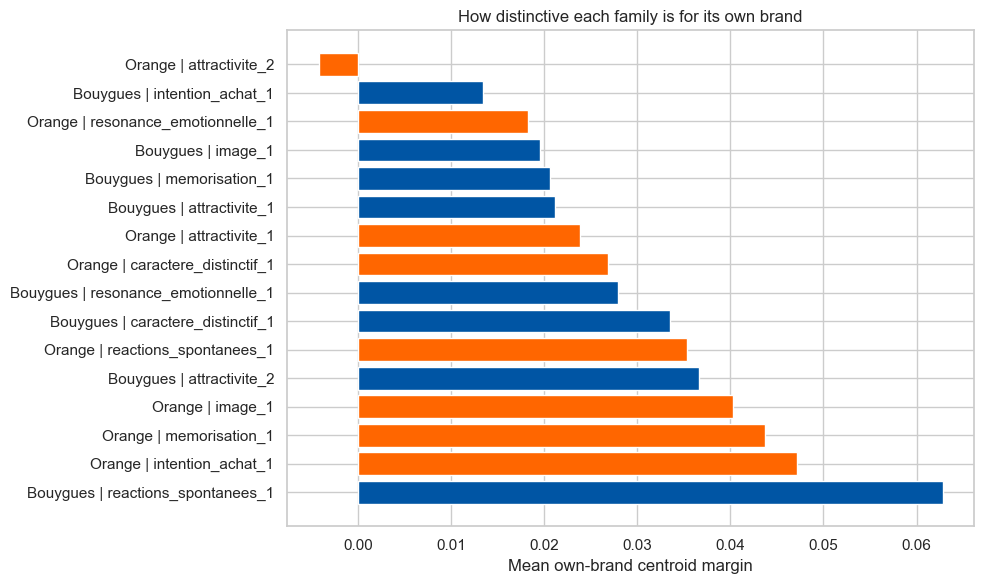

In [13]:
plt.figure(figsize=(10, 6))
dist_plot = distinctiveness.copy()
dist_plot["label"] = dist_plot["group"] + " | " + dist_plot["family"]
dist_plot = dist_plot.sort_values("mean_own_margin", ascending=False)
colors = ["#0055A4" if g == "Bouygues" else "#FF6600" for g in dist_plot["group"]]
plt.barh(dist_plot["label"], dist_plot["mean_own_margin"], color=colors)
plt.xlabel("Mean own-brand centroid margin")
plt.title("How distinctive each family is for its own brand")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inspection_family_distinctiveness.png", dpi=300)
plt.show()
plt.close()


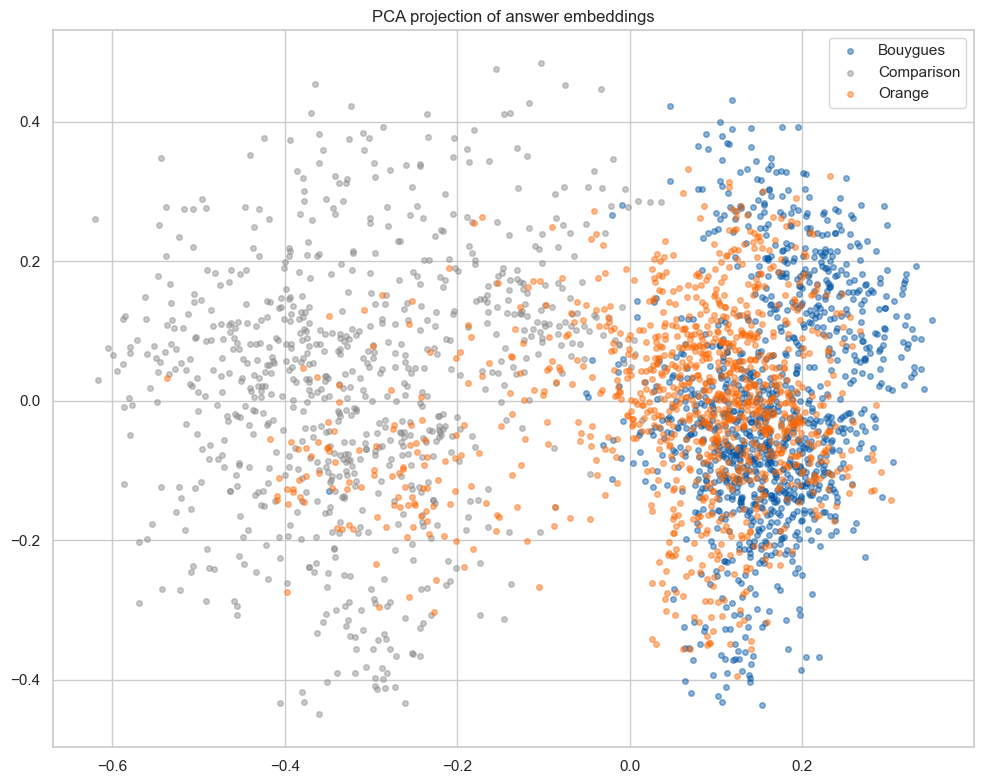

,component,explained_variance_ratio
0,PC1,0.095974
1,PC2,0.046425


In [14]:
sample_n = min(3000, len(metadata))
sampled = metadata.sample(sample_n, random_state=42).copy()
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(sampled[EMB_COLS].to_numpy(dtype=float))
sampled["pc1"] = coords[:, 0]
sampled["pc2"] = coords[:, 1]

plt.figure(figsize=(10, 8))
color_map = {"Bouygues": "#0055A4", "Orange": "#FF6600", "Comparison": "#888888"}
for group, part in sampled.groupby("group"):
    plt.scatter(part["pc1"], part["pc2"], s=16, alpha=0.45, label=group, color=color_map.get(group, "#444444"))
plt.legend()
plt.title("PCA projection of answer embeddings")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inspection_pca_sample.png", dpi=300)
plt.show()
plt.close()

pca_info = pd.DataFrame(
    {
        "component": ["PC1", "PC2"],
        "explained_variance_ratio": pca.explained_variance_ratio_,
    }
)
pca_info.to_csv(OUTPUT_DIR / "inspection_pca_variance.csv", index=False)
pca_info


In [15]:
summary_lines = []

most_cohesive = group_diagnostics.iloc[0]
least_cohesive = group_diagnostics.iloc[-1]
closest_pair = group_pairs.sort_values("centroid_cosine_similarity", ascending=False).iloc[0]
farthest_pair = group_pairs.sort_values("centroid_euclidean_distance", ascending=False).iloc[0]
most_divergent_family = family_diagnostics.iloc[0]
most_aligned_family = family_diagnostics.iloc[-1]
lowest_panelist = family_diagnostics.sort_values("mean_panelist_cosine").iloc[0]
highest_panelist = family_diagnostics.sort_values("mean_panelist_cosine").iloc[-1]
strongest_orange_lean = comparison_diagnostics.iloc[0]
strongest_bouygues_lean = comparison_diagnostics.iloc[-1]

summary_lines.append(f"Most cohesive answer space: {most_cohesive['group']} (mean distance {most_cohesive['mean_distance_to_centroid']:.3f}).")
summary_lines.append(f"Least cohesive answer space: {least_cohesive['group']} (mean distance {least_cohesive['mean_distance_to_centroid']:.3f}).")
summary_lines.append(f"Closest group centroids: {closest_pair['group_a']} vs {closest_pair['group_b']} (cosine {closest_pair['centroid_cosine_similarity']:.3f}).")
summary_lines.append(f"Farthest group centroids: {farthest_pair['group_a']} vs {farthest_pair['group_b']} (euclidean {farthest_pair['centroid_euclidean_distance']:.3f}).")
summary_lines.append(f"Most divergent Bouygues/Orange family: {most_divergent_family['family']} (cosine {most_divergent_family['cosine_similarity']:.3f}).")
summary_lines.append(f"Most aligned Bouygues/Orange family: {most_aligned_family['family']} (cosine {most_aligned_family['cosine_similarity']:.3f}).")
summary_lines.append(f"Lowest panelist-level cross-brand alignment: {lowest_panelist['family']} (mean paired cosine {lowest_panelist['mean_panelist_cosine']:.3f}).")
summary_lines.append(f"Highest panelist-level cross-brand alignment: {highest_panelist['family']} (mean paired cosine {highest_panelist['mean_panelist_cosine']:.3f}).")
summary_lines.append(f"Strongest Orange-leaning comparison family: {strongest_orange_lean['comparison_family']} (delta {strongest_orange_lean['orange_minus_bouygues']:.3f}).")
summary_lines.append(f"Strongest Bouygues-leaning comparison family: {strongest_bouygues_lean['comparison_family']} (delta {strongest_bouygues_lean['orange_minus_bouygues']:.3f}).")

summary = pd.DataFrame({"summary_line": summary_lines})
summary.to_csv(OUTPUT_DIR / "inspection_executive_summary.csv", index=False)
print("\n".join(summary_lines))
summary


Most cohesive answer space: Comparison (mean distance 0.657).
Least cohesive answer space: Orange (mean distance 0.722).
Closest group centroids: Bouygues vs Orange (cosine 0.958).
Farthest group centroids: Bouygues vs Comparison (euclidean 0.491).
Most divergent Bouygues/Orange family: reactions_spontanees_1 (cosine 0.788).
Most aligned Bouygues/Orange family: attractivite_2 (cosine 0.930).
Lowest panelist-level cross-brand alignment: intention_achat_1 (mean paired cosine 0.475).
Highest panelist-level cross-brand alignment: image_1 (mean paired cosine 0.563).
Strongest Orange-leaning comparison family: comparaison_5 (delta 0.080).
Strongest Bouygues-leaning comparison family: comparaison_3 (delta 0.039).


,summary_line
0,Most cohesive answer space: Comparison (mean distance 0.657).
1,Least cohesive answer space: Orange (mean distance 0.722).
2,Closest group centroids: Bouygues vs Orange (cosine 0.958).
3,Farthest group centroids: Bouygues vs Comparison (euclidean 0.491).
4,Most divergent Bouygues/Orange family: reactions_spontanees_1 (cosine 0.788).
5,Most aligned Bouygues/Orange family: attractivite_2 (cosine 0.930).
6,Lowest panelist-level cross-brand alignment: intention_achat_1 (mean paired cosine 0.475).
7,Highest panelist-level cross-brand alignment: image_1 (mean paired cosine 0.563).
8,Strongest Orange-leaning comparison family: comparaison_5 (delta 0.080).
9,Strongest Bouygues-leaning comparison family: comparaison_3 (delta 0.039).


In [16]:
print("saved:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(p.name)


saved:
inspection_comparison_brand_lean.png
inspection_comparison_question_diagnostics.csv
inspection_data_quality.csv
inspection_executive_summary.csv
inspection_family_alignment_scatter.png
inspection_family_diagnostics.csv
inspection_family_distinctiveness.csv
inspection_family_distinctiveness.png
inspection_family_similarity.png
inspection_group_cohesion.png
inspection_group_diagnostics.csv
inspection_group_pair_diagnostics.csv
inspection_group_text_length.png
inspection_highest_similarity_pairs.csv
inspection_lowest_similarity_pairs.csv
inspection_overview.csv
inspection_pca_sample.png
inspection_pca_variance.csv
